In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

path = 'lp_analysis_output_weth_usdc_500.csv'
df = pd.read_csv(path)
path = 'lp_analysis_output_weth_dai_events_3000.csv'
df = pd.read_csv(path)


<Axes: xlabel='vol_reward', ylabel='fee_reward'>

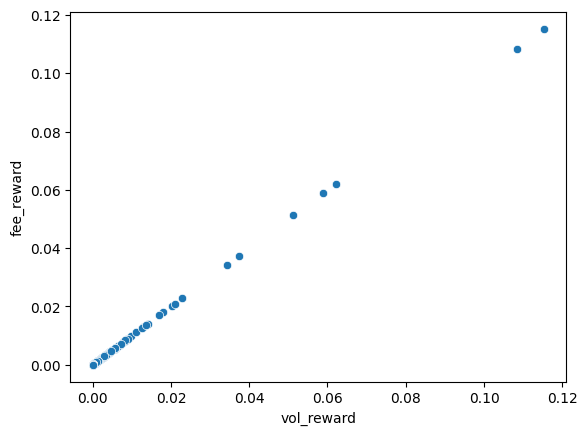

In [62]:

total_vol = df['volume'].sum()
total_fee = df['dollar_fees'].sum()

df['vol_reward'] = df['volume'] / total_vol
df['fee_reward'] = df['dollar_fees'] / total_fee

import seaborn as sns
sns.scatterplot(
    data = df,
    x = 'vol_reward',
    y = 'fee_reward'
)

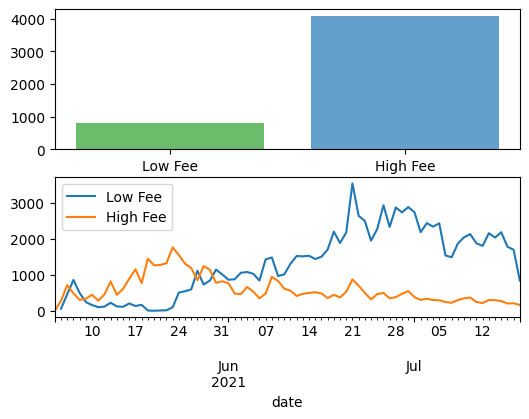

In [2]:
lp_cols_high = [i for i in high_fee.columns if ('fee' not in i) & ('inventory' not in i)]
lp_cols_low = [i for i in low_fee.columns if ('fee' not in i) & ('inventory' not in i)]

low_fee['volume_proxy'] = abs(low_fee['amount0']) + abs(low_fee['amount1'])
high_fee['volume_proxy'] = abs(high_fee['amount0']) + abs(high_fee['amount1'])

daily_vol_low = low_fee.groupby('date').size()
daily_vol_high = high_fee.groupby('date').volume_proxy.size()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=False)

daily_vol_low.plot(ax=ax2,label = 'Low Fee')
daily_vol_high.plot(ax=ax2, label = 'High Fee')

n_lps_low = len(lp_cols_low)
n_lps_high = len(lp_cols_high)

ax1.bar(['Low Fee', 'High Fee'], [n_lps_low, n_lps_high], color=['tab:green', 'tab:blue'], alpha=0.7)
plt.legend()


In [3]:

exclude_cols = ['amount0','amount1','event','date','evt_block_time','price','pool_liquidity','volume_proxy',"('0x', 0.0, 0.0)"]
just_lps = [i for i in lp_cols_high if i not in exclude_cols]
high_lps = pd.DataFrame(index = just_lps)

for lp in just_lps:
    high_lps.loc[lp,'position_size'] = high_fee[lp].astype(float).max()
    high_lps.loc[lp,'lifetime'] = (high_fee[lp] > 0).sum()
    fee_0_str = lp + '_fee_0'
    fee_1_str = lp + '_fee_1'
    dollars_fees = (high_fee.price * high_fee[fee_0_str]) + (high_fee[fee_1_str]) #double check this 
    high_lps.loc[lp,'total_fees'] = dollars_fees.sum()

    

In [4]:
exclude_cols = ['amount0','amount1','event','date','evt_block_time',
                'price','pool_liquidity','volume_proxy',"('0x', 0.0, 0.0)"]

just_lps_low = [i for i in lp_cols_low if i not in exclude_cols]

low_lps = pd.DataFrame(index=just_lps_low)

for lp in just_lps_low:
    low_lps.loc[lp, 'position_size'] = low_fee[lp].astype(float).max()
    low_lps.loc[lp, 'lifetime'] = (low_fee[lp] > 0).sum()
    
    fee_0_str = lp + '_fee_0'
    fee_1_str = lp + '_fee_1'
    
    dollars_fees = (low_fee['price'] * low_fee[fee_0_str]) + low_fee[fee_1_str]
    low_lps.loc[lp, 'total_fees'] = dollars_fees.sum()

In [5]:
# from scipy import stats 
# import seaborn as sns

# n_bins = 10
# labels = list(range(n_bins))

# high_lps['liquidity_decile'] = pd.qcut(high_lps['position_size'], q=n_bins, labels=labels,duplicates='drop').astype(int)
# high_lps['lifetime_decile'] = pd.qcut(high_lps['lifetime'], q=n_bins, labels=labels).astype(int)
# high_lps['fee_decile'] = pd.qcut(high_lps['total_fees'], q=n_bins, labels=labels).astype(int)
# high_lps['position_size*lifetime'] = high_lps['position_size'] * high_lps['lifetime']
# high_lps['total_fees'] = high_lps.total_fees

# sns.scatterplot(
#     data = high_lps,
#     x = 'position_size*lifetime',
#     y = 'total_fees',
#     hue = 'fee_decile',
#     palette='tab10',
# )

# plt.xlim(-3,3)
# plt.ylim(-3,3)

In [6]:
n_bins = 10
labels = list(range(n_bins))

# low_lps['liquidity_decile'] = pd.qcut(low_lps['position_size'], q=n_bins, labels=labels).astype(int)
# low_lps['lifetime_decile'] = pd.qcut(low_lps['lifetime'], q=n_bins, labels=labels).astype(int)
# low_lps['fee_decile'] = pd.qcut(low_lps['total_fees'], q=n_bins, labels=labels).astype(int)
high_lps["position_size*lifetime"] = high_lps["position_size"] * high_lps["lifetime"]
high_lps["total_fees"] = high_lps.total_fees
low_lps["position_size*lifetime"] = low_lps["position_size"] * low_lps["lifetime"]
low_lps['total_fees'] = low_lps.total_fees

# sns.scatterplot(
#     data=low_lps,
#     x='position_size*lifetime',
#     y='total_fees',
#     hue='fee_decile',
#     palette='tab10',
#     alpha=0.7
# )

# plt.xlim(-3, 3)
# plt.ylim(-3, 3)
# plt.xlabel('Position Size * Lifetime')
# plt.ylabel('Total Fees')
# plt.title('Low Fee LPs: Fees vs Position Size * Lifetime by Fee Decile')
# plt.show()

In [109]:
d_ = pd.read_csv('data/weth_dai_3000.csv')
d = pd.read_csv('data/weth_usdc_3000.csv')

d.iloc[0].evt_tx_hash,d_.iloc[0].evt_tx_hash

('0x89d75075eaef8c21ab215ae54144ba563b850ee7460f89b2a175fd0e267ed330',
 '0x8c2161cdf81dacef87759fa8f1f8f94dc9de293b757939fcf0fdc866e80ed052')

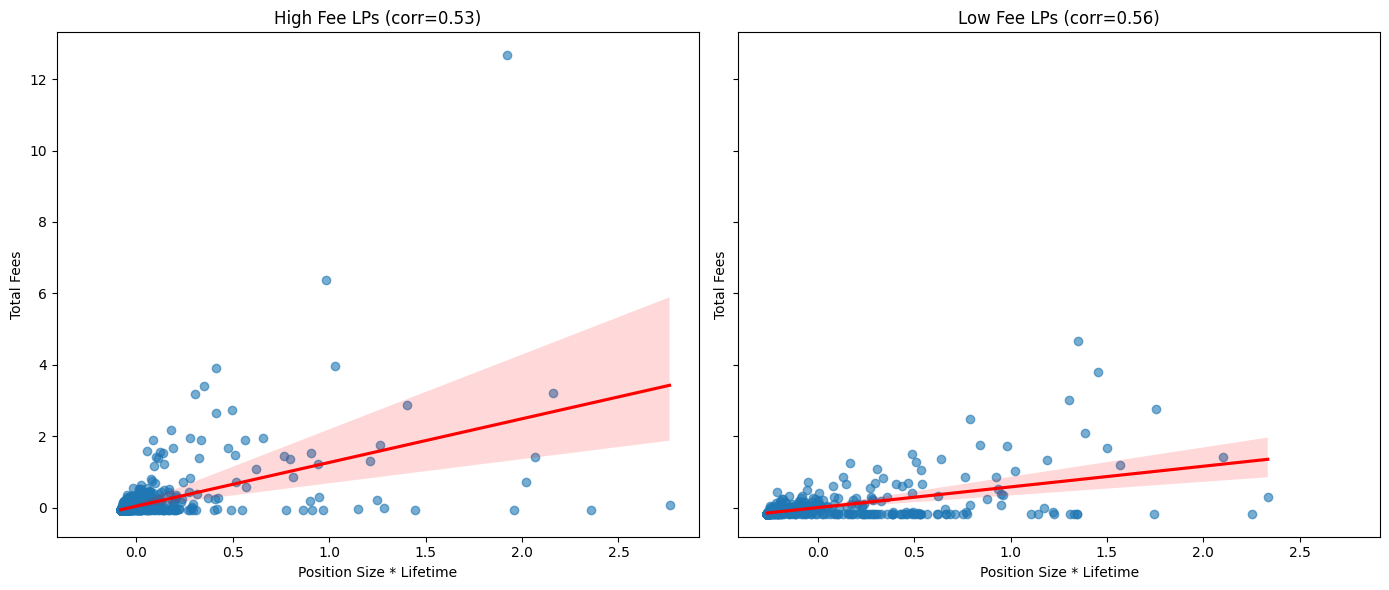

In [7]:
import seaborn as sns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),sharey=True,sharex=True)


high_lps['fee_z'] = stats.zscore(high_lps.total_fees)
low_lps['fee_z'] = stats.zscore(low_lps.total_fees)
high_lps['lifetime_z'] = stats.zscore(high_lps['position_size*lifetime'])
low_lps['lifetime_z'] = stats.zscore(low_lps['position_size*lifetime'])


high_lps_ = high_lps[abs(high_lps.lifetime_z) < 3]
low_lps_ = low_lps[abs(low_lps.lifetime_z) < 3]

high_corr = high_lps_.corr().loc["total_fees", "position_size*lifetime"]
low_corr = low_lps_.corr().loc["total_fees", "position_size*lifetime"]


sns.regplot(
    data=high_lps_,
    x='lifetime_z',
    y='fee_z',
    ax=ax1,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)
ax1.set_title(f'High Fee LPs (corr={high_corr:.2f})')

sns.regplot(
    data=low_lps_,
    x='lifetime_z',
    y='fee_z',
    ax=ax2,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)
ax2.set_title(f'Low Fee LPs (corr={low_corr:.2f})')

for ax in (ax1, ax2):
    ax.set_xlabel('Position Size * Lifetime')
    ax.set_ylabel('Total Fees')

plt.tight_layout()
plt.show()

In [8]:
#1. improve the quality of the summary overview looks <--
#2. actually evaluate lp staking numbers <-- importante
#3. compare group of lps and look at performance.

In [9]:
for _df in [high_fee,low_fee]:
    # quantities of interest at the event level
    # _df.ffill(inplace=True)
    _df["evt_block_time"] = pd.to_datetime(_df["evt_block_time"])
    # totals across lps
    _df['liquidity_at_tick'] = _df['pool_liquidity'].astype(float).ffill()/10**18
    _df["total_liquidity"] = _df.filter(regex="\\)$").sum(axis=1) / 10**18
    _df["liquidity_at_tick_to_total"] = (_df["liquidity_at_tick"] / _df["total_liquidity"])
    _df["total_fee_0"] = _df.filter(regex="_fee_0").sum(axis=1)/10**18
    _df["total_fee_1"] = _df.filter(regex="_fee_1").sum(axis=1) / 10**18
    _df["total_inv_0"] = _df.filter(regex="_inventory_0").sum(axis=1) / 10**18
    _df["total_inv_1"] = _df.filter(regex="_inventory_1").sum(axis=1) / 10**18
    # accumulations & values of things M2M
    _df["total_fee_0_acc"] = _df["total_fee_0"].cumsum()
    _df["total_fee_1_acc"] = _df["total_fee_1"].cumsum()
    _df["total_fee_acc_M2M"] = (
        _df["total_fee_0_acc"] + (1 / _df["price"]) * _df["total_fee_1_acc"]
    )
    # "tvl"
    _df["total_inv_value_M2M"] = (
        _df["total_inv_0"] + (1 / _df["price"]) * _df["total_inv_1"]
    )

    # swap stuff
    _df["swaps.dollars_in"] = np.where(
        _df["event"].eq("swap") & (_df["amount0"] > 0), _df["amount0"], 0
    ) + np.where(
        _df["event"].eq("swap") & (_df["amount1"] > 0),(1 / _df["price"])*_df["amount1"], 0
    )/10**18
    _df["swaps.dollars_in_acc"] = _df["swaps.dollars_in"].cumsum()/10**18

    _df["num_swaps"] = _df['event'].eq("swap").cumsum()
    _df["num_mints"] = _df["event"].eq("mint").cumsum()
    _df["num_burns"] = _df["event"].eq("burn").cumsum()
    # lp stuff
    _df["num_alive_lps"] = (_df.filter(regex="\\)$")>0).sum(axis=1)
    _df["total_liquidity_per_lp"] = _df['total_liquidity']/_df['num_alive_lps']
    _df["dollar_fees_acc_per_unit_liquidity"] = (
        _df["total_fee_acc_M2M"] / _df["total_liquidity"]
    )
    _df["dollar_fees_acc_per_lp"] = _df["total_fee_acc_M2M"]/_df["num_alive_lps"]

    _df["dollar_fees_per_lp"] = _df["total_fee_acc_M2M"] / _df["num_alive_lps"]

# 100000
# 45000 swap,mints,burns
# 145000 row thing --> 75 days

regex = "date|total|swaps|num|liquidity_at_tick|total_liquidity_per_lp|dollar_fees_acc_per_unit_liquidity|dollar_fees_acc_per_lp"

df = pd.merge(
        high_fee.filter(regex=regex).groupby('date').last().add_prefix("high_fee."),
        low_fee.filter(regex=regex).groupby('date').last().add_prefix("low_fee."),left_index=True, right_index=True, how="outer")

# add ratios at the HOUR level
for col in df.filter(regex='high_fee.').columns:
    quantity = col.lstrip("high_fee.")
    df[f'low2high.{quantity}'] = df[f'low_fee.{quantity}']/df[f'high_fee.{quantity}']
pd.options.plotting.backend='plotly'
df.plot(template='plotly_dark')